# Energy Reconstruction Using CNN

## General Notes:
This notebook is designed for regression convolutional neural networks used to reconstruct the energy of a cosmic ray primary. It assumes all input is normalized as a best-practice.

In [47]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import os
from glob import glob
from keras.models import load_model
from data_tools_clipPercent import load_preprocessed, dataPrep, getCut

## Model Selection

In [48]:
# Edit this file path to the models folder containing .h5 and .npy files for each model.
modelPrefix = r'C:\Users\mkrit\Documents\RESEARCH\models\New'
#os.getcwd()+'\\models'

# Edit this file path to the folder containing the simulationg data.
simPrefix = os.getcwd()+'\\sim_data'

# Option to change font size for all labels within this notebook
labelParams = {'fontsize':16}

In [49]:
# List of available models

modelList = sorted(glob('%s\\*.h5' % modelPrefix))
modelList = [os.path.basename(m)[:-3] for m in modelList]

paramList = sorted(glob('%s\\*.npy' % modelPrefix))
paramList = [os.path.basename(p)[:-4] for p in paramList]

print('Available models:', sorted(set(modelList).intersection(paramList)))
print('\nModels without parameter files:', sorted(set(modelList).difference(paramList)))

Available models: ['kriti_NoClip_zeroGap0', 't_clip10_zeroGap0', 't_clip10_zeroGap1', 't_clip12_zeroGap0', 't_clip14_zeroGap0', 't_clip15__zeroGap0', 't_clip5_zeroGap0', 't_clip5_zeroGap1', 't_clip6_zeroGap0', 't_clip7__zeroGap0', 't_clip7p5_zeroGap0', 't_clip8_zeroGap0', 't_clip9_zeroGap0 (2)', 't_clip9_zeroGap1', 't_clip9p5__zeroGap0', 't_clip_new7p5__zeroGap0']

Models without parameter files: []


In [50]:
# Keys you want to study
# Available models will appear above

keyList = ['t_clip9p5__zeroGap0','t_clip9_zeroGap1','t_clip8_zeroGap0','t_clip15__zeroGap0','t_clip10_zeroGap1', 't_clip5_zeroGap1','t_clip6_zeroGap0','t_clip12_zeroGap0','t_clip7__zeroGap0','t_clip_new7p5__zeroGap0']
# Example: keyList = ['test0', 'test1']

labels = {'t_clip9p5__zeroGap0':'t_clip9p5__zeroGap0','t_clip9_zeroGap1':'t_clip9_zeroGap1','t_clip8_zeroGap0':'t_clip8_zeroGap0','t_clip15__zeroGap0':'t_clip15__zeroGap0','t_clip10_zeroGap1':'t_clip10_zeroGap1','t_clip5_zeroGap1':'t_clip5_zeroGap1','t_clip7p5_zeroGap0':'t_clip7p5_zeroGap0','t_clip6_zeroGap0':'t_clip6_zeroGap0','t_clip12_zeroGap0':'t_clip12zeroGap0','t_clip_new7p5__zeroGap0':'t_clip_new7p5__zeroGap0','t_clip7__zeroGap0':'t_clip7__zeroGap0'}
# Example: labels = {'test0':'label0', 'test1':'label1'}

# Automatic intake of parameters from parameter files
p = {}
for key in keyList:
    d = np.load('%s\\%s.npy' % (modelPrefix, key), allow_pickle=True)
    p[key] = d.item()
    print(key, ':', p[key])

t_clip9p5__zeroGap0 : {'q': None, 't': None, 'normed': True, 'reco': 'plane', 'cosz': False, 't_shift': True, 't_clip': 9.5}
t_clip9_zeroGap1 : {'q': None, 't': None, 'normed': True, 'reco': 'plane', 'cosz': False, 't_shift': True, 't_clip': 9}
t_clip8_zeroGap0 : {'q': None, 't': None, 'normed': True, 'reco': 'plane', 'cosz': False, 't_shift': True, 't_clip': 8}
t_clip15__zeroGap0 : {'q': None, 't': None, 'normed': True, 'reco': 'plane', 'cosz': False, 't_shift': True, 't_clip': 15}
t_clip10_zeroGap1 : {'q': None, 't': None, 'normed': True, 'reco': 'plane', 'cosz': False, 't_shift': True, 't_clip': 10}
t_clip5_zeroGap1 : {'q': None, 't': None, 'normed': True, 'reco': 'plane', 'cosz': False, 't_shift': True, 't_clip': 5}
t_clip6_zeroGap0 : {'q': None, 't': None, 'normed': True, 'reco': 'plane', 'cosz': False, 't_shift': True, 't_clip': 6}
t_clip12_zeroGap0 : {'q': None, 't': None, 'normed': True, 'reco': 'plane', 'cosz': False, 't_shift': True, 't_clip': 12}
t_clip7__zeroGap0 : {'q': No

## Assessment Data

In [51]:
# Load data, x in four layers (q1, q2, t1, t2) and y as a dictionary with event-level parameters
x, y = load_preprocessed(simPrefix, 'assessment')

Percentage of events with a NaN: 2.68


In [52]:
# Event-level parameters
# True values
theta, phi = y['dir'].transpose()
theta = np.pi - theta  # Define 0 degrees as overhead

#print(phi)


## Notes

This notebook is designed to compare multiple models for beginners in machine learning

## Model Preperation

In [53]:
models = {}
recoE = {}

# Calculate reconstructed energies. This can take a bit, but should print out info on each key as it works
for key in keyList:

    # Comment these two lines if you want to rerun your energy reconstructions each time
    if key in models.keys():
        continue

    print('Working on %s...' % key)
    # Note: very sensitive to tensorflow/keras version.
    models[key] = load_model('%s/%s.h5' % (modelPrefix, key)) # Edit file path
    
    # Configure input data
    x_i = dataPrep(x, y, **p[key])
    comp = y['comp']
    energy = y['energy']  
    
    print('Model parameters')
    print(p[key])
    
    # Models should only output energy
    recoE[key] = models[key].predict([x_i[0], x_i[1]]).flatten()

Working on t_clip9p5__zeroGap0...
Model parameters
{'q': None, 't': None, 'normed': True, 'reco': 'plane', 'cosz': False, 't_shift': True, 't_clip': 9.5}
1907/1907 [==============================] - 13s 6ms/step
Working on t_clip9_zeroGap1...
Model parameters
{'q': None, 't': None, 'normed': True, 'reco': 'plane', 'cosz': False, 't_shift': True, 't_clip': 9}
1907/1907 [==============================] - 11s 5ms/step
Working on t_clip8_zeroGap0...
Model parameters
{'q': None, 't': None, 'normed': True, 'reco': 'plane', 'cosz': False, 't_shift': True, 't_clip': 8}
1907/1907 [==============================] - 9s 5ms/step
Working on t_clip15__zeroGap0...
Model parameters
{'q': None, 't': None, 'normed': True, 'reco': 'plane', 'cosz': False, 't_shift': True, 't_clip': 15}
1907/1907 [==============================] - 9s 5ms/step
Working on t_clip10_zeroGap1...
Model parameters
{'q': None, 't': None, 'normed': True, 'reco': 'plane', 'cosz': False, 't_shift': True, 't_clip': 10}
1907/1907 [====

## Plotting Parameters

In [54]:
ebins = np.linspace(5, 8, 181)
evalues = (ebins[:-1] + ebins[1:]) / 2

cutNames = ['No Cut', 'Quality Cut']
ncols, nrows = len(cutNames), len(keyList)


## Energy Reconstruction Plots

### Total Energy Resolution

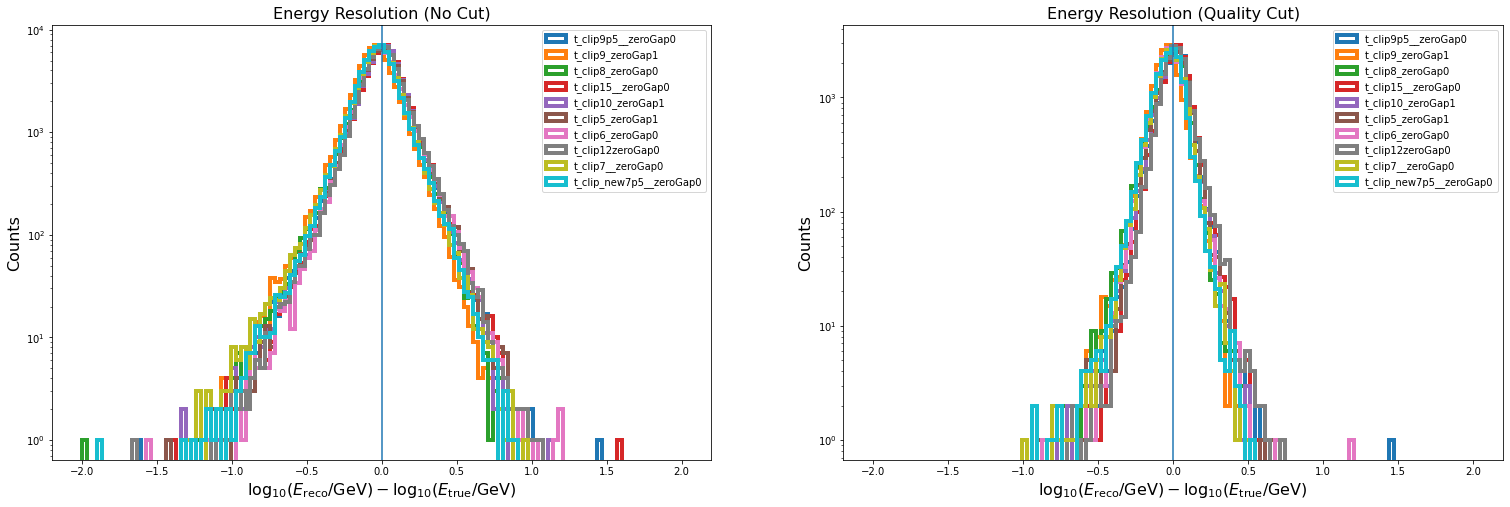

In [55]:
histArgs = {'range':(-2,2), 'bins':121, 'histtype':'step', 'log':True, 'linewidth':4}
fig, axs = plt.subplots(figsize=(13*ncols, 8), ncols=ncols)
for i, cutName in enumerate(cutNames):
    ax = axs[i]
    for j, key in enumerate(keyList):
        cut = getCut(cutName, x, y, p, recoE, key)
        ax.hist((recoE[key][cut] - energy[cut]), label=labels[key], **histArgs)
    ax.set_title('Energy Resolution (%s)' % cutName, **labelParams)
    ax.set_xlabel(r'$\log_{10}(E_{\mathrm{reco}}/\mathrm{GeV}) - \log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$', **labelParams)
    ax.set_ylabel('Counts', **labelParams)
    ax.legend()
    ax.axvline()



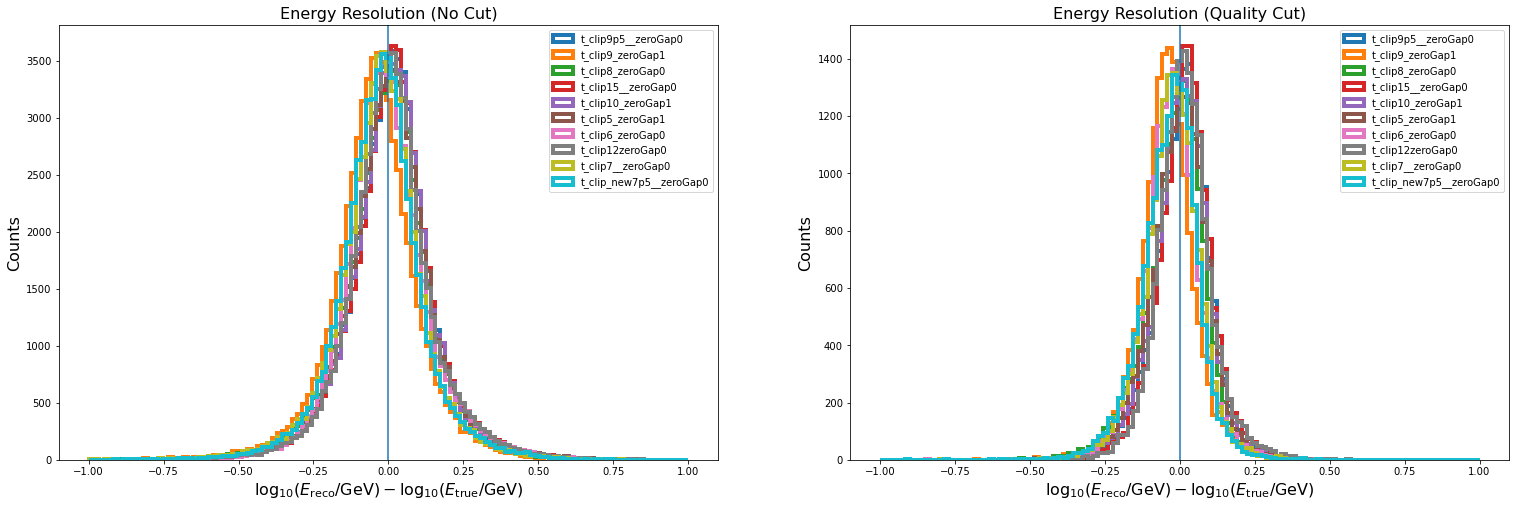

In [56]:
# Plot energy resolution

histArgs = {'range':(-1,1), 'bins':121, 'histtype':'step', 'linewidth':4}
fig, axs = plt.subplots(figsize=(13*ncols, 8), ncols=ncols)

for i, cutName in enumerate(cutNames):
    ax = axs[i]
    for j, key in enumerate(keyList):
        cut = getCut(cutName, x, y, p, recoE, key)
        ax.hist((recoE[key][cut] - energy[cut]), label=labels[key], **histArgs)
    ax.set_title('Energy Resolution (%s)' % cutName, **labelParams)
    ax.set_xlabel(r'$\log_{10}(E_{\mathrm{reco}}/\mathrm{GeV}) - \log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$', **labelParams)
    ax.set_ylabel('Counts', **labelParams)
    ax.legend()
    ax.axvline()


In [57]:
for key in keyList:
    for i, cutName in enumerate(cutNames):
        cut = getCut(cutName, x, y, p, recoE, key)
        median, err_min, err_max = np.percentile(recoE[key][cut] - energy[cut], (50,16,84))
        print('Energy resolution for %s (%s): %.03f +%.03f %.03f' % (key, cutName, median, err_max, err_min))
    print()

Energy resolution for t_clip9p5__zeroGap0 (No Cut): 0.011 +0.127 -0.118
Energy resolution for t_clip9p5__zeroGap0 (Quality Cut): 0.015 +0.091 -0.076

Energy resolution for t_clip9_zeroGap1 (No Cut): -0.042 +0.081 -0.168
Energy resolution for t_clip9_zeroGap1 (Quality Cut): -0.041 +0.038 -0.124

Energy resolution for t_clip8_zeroGap0 (No Cut): 0.001 +0.122 -0.135
Energy resolution for t_clip8_zeroGap0 (Quality Cut): -0.005 +0.074 -0.109

Energy resolution for t_clip15__zeroGap0 (No Cut): 0.015 +0.135 -0.111
Energy resolution for t_clip15__zeroGap0 (Quality Cut): 0.019 +0.097 -0.067

Energy resolution for t_clip10_zeroGap1 (No Cut): 0.011 +0.128 -0.116
Energy resolution for t_clip10_zeroGap1 (Quality Cut): 0.008 +0.087 -0.084

Energy resolution for t_clip5_zeroGap1 (No Cut): 0.005 +0.129 -0.121
Energy resolution for t_clip5_zeroGap1 (Quality Cut): 0.003 +0.086 -0.094

Energy resolution for t_clip6_zeroGap0 (No Cut): -0.011 +0.121 -0.127
Energy resolution for t_clip6_zeroGap0 (Quality Cut

In [58]:
# Summary parameters

for key in keyList:
    for i, cutName in enumerate(cutNames):
        cut = getCut(cutName, x, y, p, recoE, key)
        median, err_min, err_max = np.percentile(recoE[key][cut] - energy[cut], (50,16,84))
        print('Energy resolution for %s (%s): %.03f +%.03f %.03f' % (key, cutName, median, err_max, err_min))
    print()

Energy resolution for t_clip9p5__zeroGap0 (No Cut): 0.011 +0.127 -0.118
Energy resolution for t_clip9p5__zeroGap0 (Quality Cut): 0.015 +0.091 -0.076

Energy resolution for t_clip9_zeroGap1 (No Cut): -0.042 +0.081 -0.168
Energy resolution for t_clip9_zeroGap1 (Quality Cut): -0.041 +0.038 -0.124

Energy resolution for t_clip8_zeroGap0 (No Cut): 0.001 +0.122 -0.135
Energy resolution for t_clip8_zeroGap0 (Quality Cut): -0.005 +0.074 -0.109

Energy resolution for t_clip15__zeroGap0 (No Cut): 0.015 +0.135 -0.111
Energy resolution for t_clip15__zeroGap0 (Quality Cut): 0.019 +0.097 -0.067

Energy resolution for t_clip10_zeroGap1 (No Cut): 0.011 +0.128 -0.116
Energy resolution for t_clip10_zeroGap1 (Quality Cut): 0.008 +0.087 -0.084

Energy resolution for t_clip5_zeroGap1 (No Cut): 0.005 +0.129 -0.121
Energy resolution for t_clip5_zeroGap1 (Quality Cut): 0.003 +0.086 -0.094

Energy resolution for t_clip6_zeroGap0 (No Cut): -0.011 +0.121 -0.127
Energy resolution for t_clip6_zeroGap0 (Quality Cut

### Energy resolution as a function of zenith

In [59]:
coszbins = np.linspace(0.4,1,20)
coszvalues = (coszbins[1:]+coszbins[:-1])/2

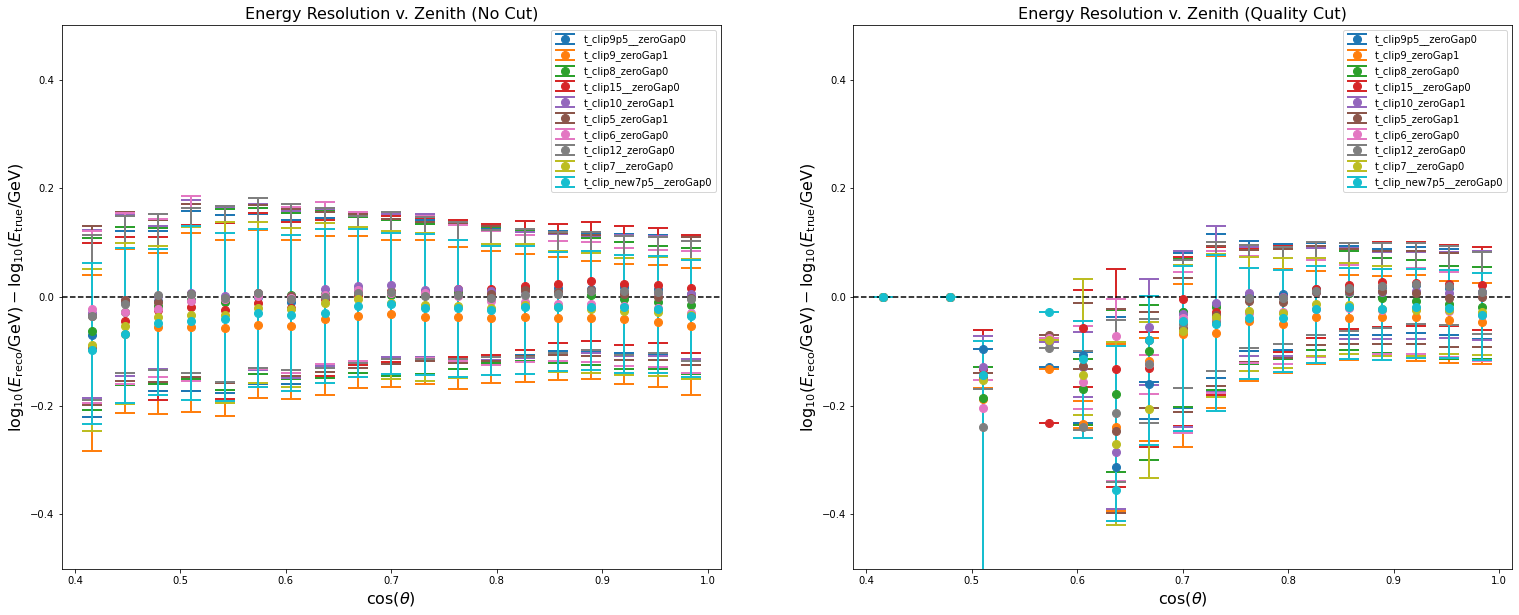

[ True False False ... False False False]
[5.6630645 5.932578  5.8267074 ... 6.4613047 6.3092084 6.496967 ]


In [60]:
kwargs = {'fmt':'.',
          'markersize':16,
          'elinewidth':2,
          'capsize':10,
          'capthick':2}
fig, axs = plt.subplots(figsize=(13*ncols, 10), ncols=ncols)

for i, cutName in enumerate(cutNames):
    ax = axs[i]
    for k, key in enumerate(keyList):
        array_info = np.zeros(shape=(len(coszvalues), 3))
        cut = getCut(cutName, x, y, p,recoE, key)
        binned_zenith = np.digitize(np.cos(theta)[cut], coszbins) - 1
        
        for j in range(len(coszvalues)):
            coszcut = (binned_zenith == j)
            
            temp_events = recoE[key][cut][coszcut]
            if len(temp_events) != 0:
                array_info[j] = np.percentile(temp_events - energy[cut][coszcut], (50, 16, 84))

        median, err_min, err_max = np.transpose(array_info)
        #print(median)
        ax.errorbar(coszvalues, median, yerr=(median-err_min, err_max-median), label=key, **kwargs)
    
    ax.axhline(color='k', ls='--')
    ax.set_title('Energy Resolution v. Zenith (%s)' % cutName, **labelParams)
    ax.set_xlabel(r'$\cos(\theta)$', **labelParams)
    ax.set_ylabel(r'$\log_{10}(E_{\mathrm{reco}}/\mathrm{GeV}) - \log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$', **labelParams)
    ax.set_ylim(-0.5, 0.5)
    ax.legend()
    
plt.show()
print(coszcut)
print(temp_events)

In [61]:
#energy resolution v clipping percentage


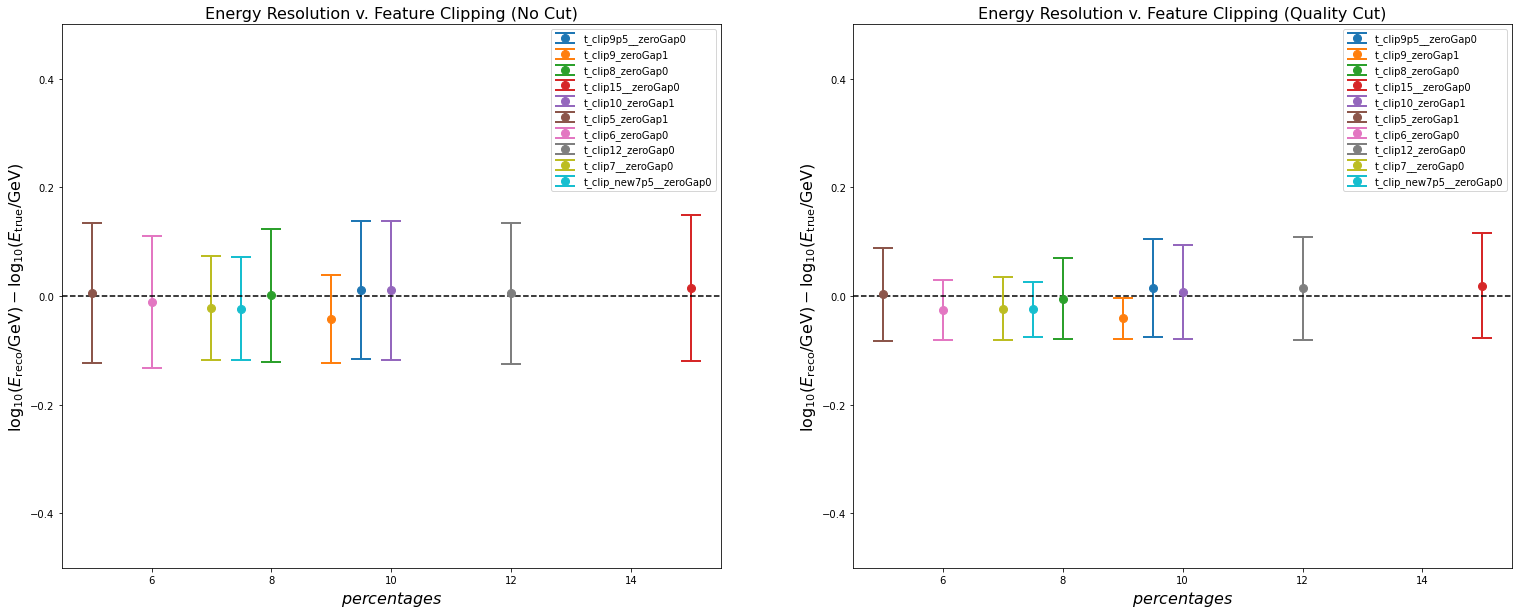

In [62]:
# Graph of energy resolution as function of clipping percentage

    #print(p['t_clip'])


kwargs = {'fmt':'.',
          'markersize':16,
          'elinewidth':2,
          'capsize':10,
          'capthick':2}
fig, axs = plt.subplots(figsize=(13*ncols, 10), ncols=ncols)

# Summary parameters

for i, cutName in enumerate(cutNames):
    ax = axs[i]
    cut = getCut(cutName, x, y, p, recoE, key)
        
    for k, key in enumerate(keyList):
        median, err_min, err_max = np.percentile(recoE[key][cut] - energy[cut], (50,16,84),)
        #out=[]
        #out.append(median)
        
        percents=[]
        percents.append(p[key]['t_clip'])
        
        error=[err_max]
    #print(out)
        
    
        ax.errorbar(percents, median, yerr=error, label=key, **kwargs)
    
    ax.axhline(color='k', ls='--')
    ax.set_title('Energy Resolution v. Feature Clipping (%s)' % cutName, **labelParams)
    ax.set_xlabel(r'$percentages$', **labelParams)
    ax.set_ylabel(r'$\log_{10}(E_{\mathrm{reco}}/\mathrm{GeV}) - \log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$', **labelParams)
    ax.set_ylim(-0.5, 0.5)
    ax.legend()

plt.show()

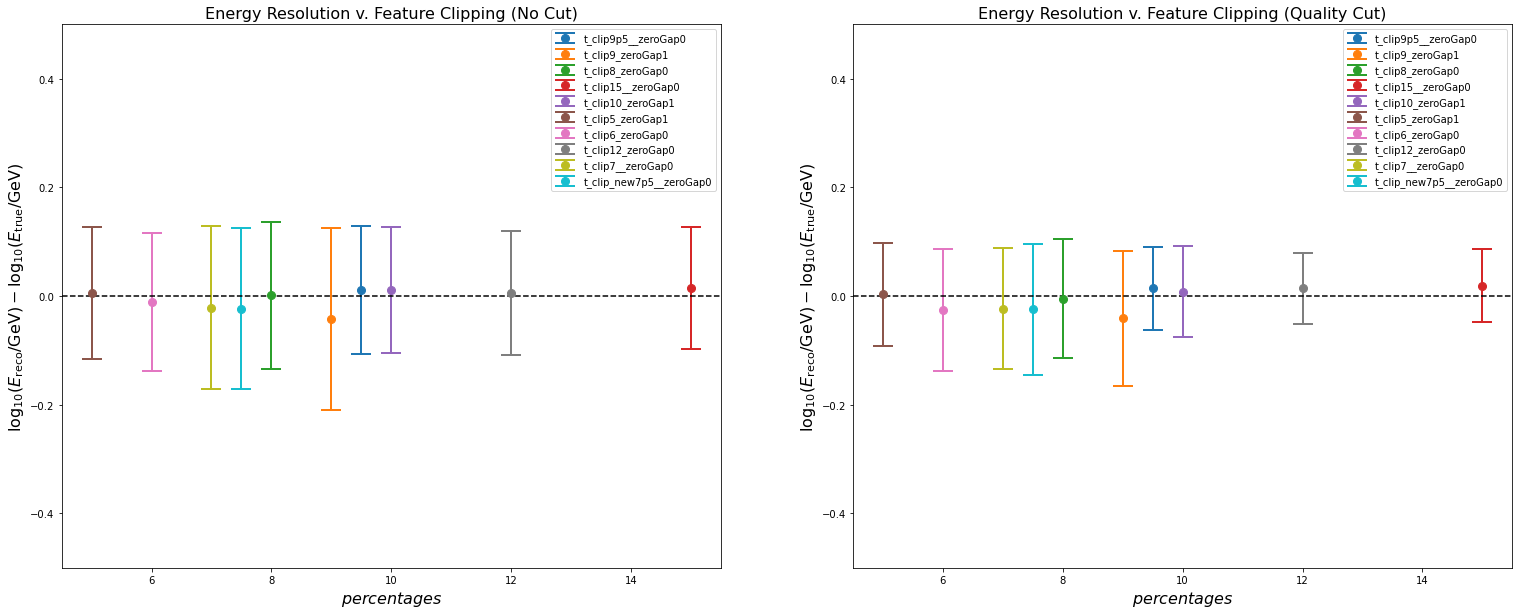

In [63]:
# Graph of energy resolution as function of clipping percentage

    #print(p['t_clip'])


kwargs = {'fmt':'.',
          'markersize':16,
          'elinewidth':2,
          'capsize':10,
          'capthick':2}
fig, axs = plt.subplots(figsize=(13*ncols, 10), ncols=ncols)

# Summary parameters

for i, cutName in enumerate(cutNames):
    ax = axs[i]
    cut = getCut(cutName, x, y, p, recoE, key)
        
    for k, key in enumerate(keyList):
        median, err_min, err_max = np.percentile(recoE[key][cut] - energy[cut], (50,16,84),)
        #out=[]
        #out.append(median)
        
        percents=[]
        percents.append(p[key]['t_clip'])
        
        error=[err_min]
    #print(out)
        
    
        ax.errorbar(percents, median, yerr=error, label=key, **kwargs)
    
    ax.axhline(color='k', ls='--')
    ax.set_title('Energy Resolution v. Feature Clipping (%s)' % cutName, **labelParams)
    ax.set_xlabel(r'$percentages$', **labelParams)
    ax.set_ylabel(r'$\log_{10}(E_{\mathrm{reco}}/\mathrm{GeV}) - \log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$', **labelParams)
    ax.set_ylim(-0.5, 0.5)
    ax.legend()

plt.show()

### Two-Dimensional Visualization

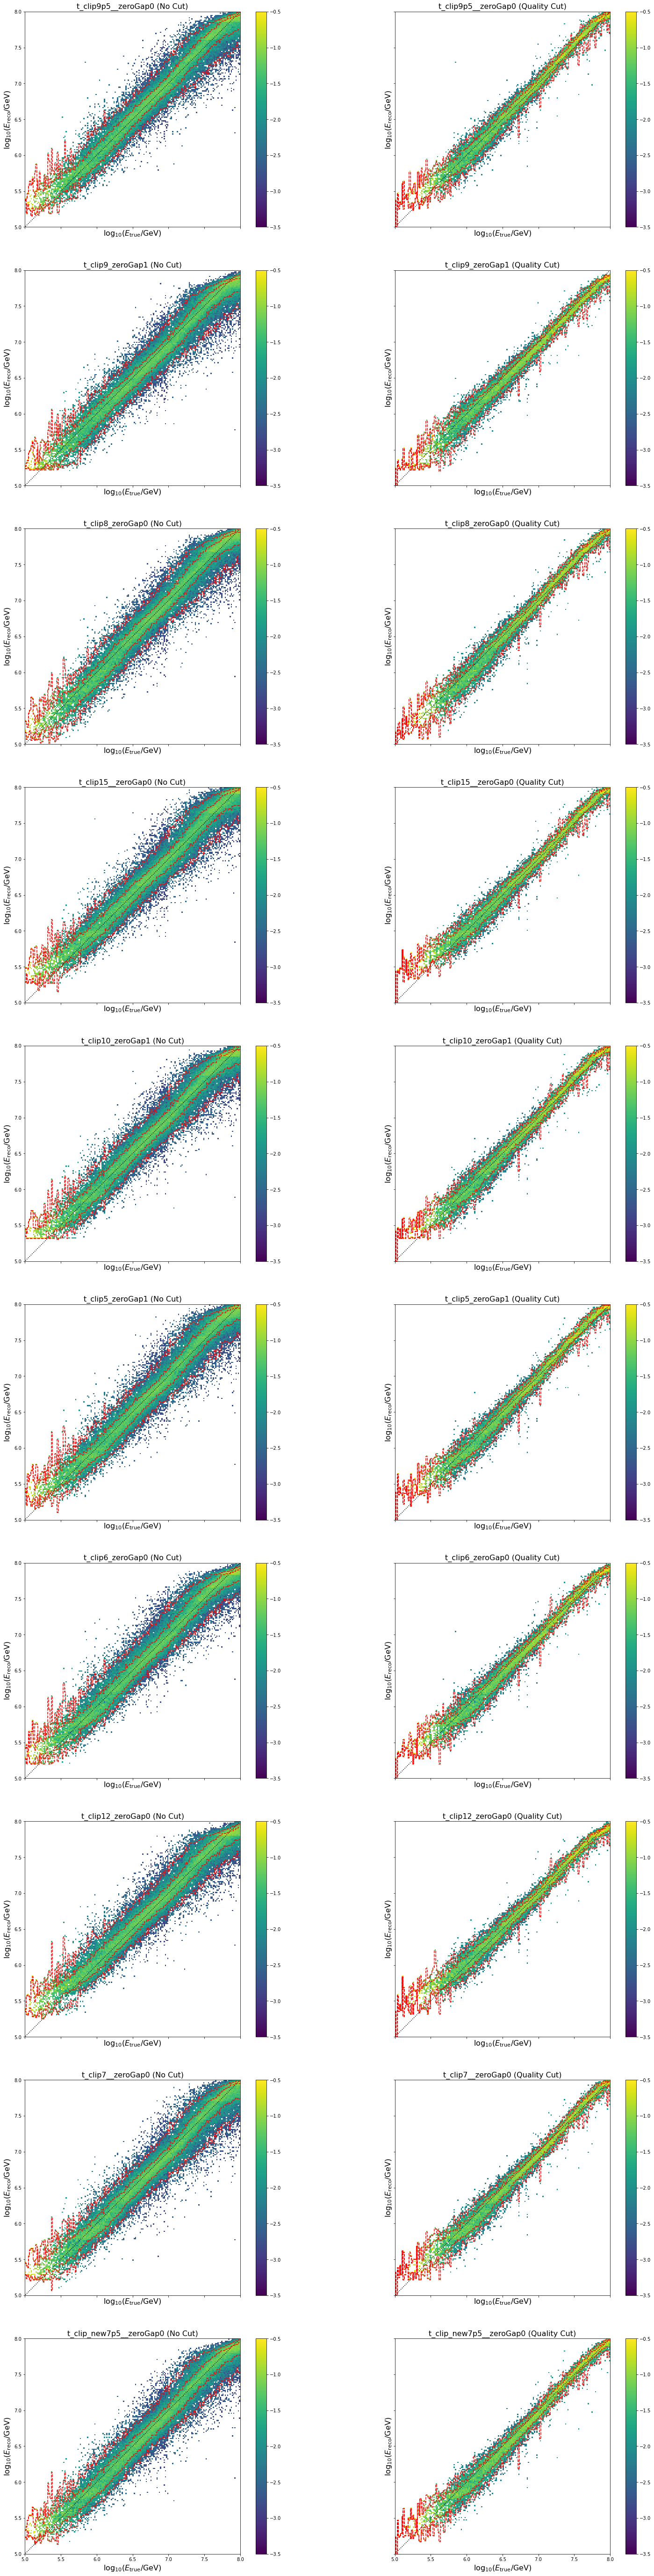

In [64]:
np.seterr(divide = 'ignore')

fig, axs = plt.subplots(figsize=(13*ncols, 10*nrows), ncols=ncols, nrows=nrows, 
                        sharex=True, sharey=True)

for i, key in enumerate(keyList):
    for j, cutName in enumerate(cutNames):
        
        ax = axs[i, j] if len(keyList) > 1 else axs[j]
        cut = getCut(cutName, x, y, p, recoE, key)
        
        h, xedges, yedges = np.histogram2d(recoE[key][cut], energy[cut], bins=(ebins, ebins), 
                                           normed=False, weights=None)
        # Normalize
        ntot = np.sum(h, axis=0).astype(float)
        ntot[ntot==0] = 1.
        h /= ntot
        
        # Create contours
        contourValues = [0.025, 0.16, 0.84, 0.975]
        contourList = [[] for i in contourValues]
        for c, col in enumerate(h.transpose()):
            ccol = col.cumsum()
            for l, val in zip(contourList, contourValues):
                try: l += [np.where(ccol > val)[0][0]]
                except IndexError:
                    l += [0]
        for l in contourList:
            l.insert(0, l[0])
            if i >= len(contourList) / 2:
                l = [j+1 for j in l]     
        ax.plot(evalues, evalues, 'k', ls=':')
        for l in contourList:
            ax.step(ebins, ebins[l], color='red', linestyle='--')
        
        # Plot on a log scale
        extent = [yedges[0], yedges[-1], xedges[0], xedges[-1]]
        im = ax.imshow(np.log10(h), extent=extent, origin='lower', interpolation='none', vmin=-3.5, vmax=-0.5)
        ax.set_title('%s (%s)' % (key, cutName), **labelParams)
        ax.set_xlabel(r'$\log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$', **labelParams)
        ax.set_ylabel(r'$\log_{10}(E_{\mathrm{reco}}/\mathrm{GeV})$', **labelParams)
        fig.colorbar(im, ax=ax)